# Exploring TCKDB

**A guided tour of a live Thermochemical & Kinetics Database.**

TCKDB stores computational-chemistry results — species, thermodynamics, reactions,
rate coefficients, pressure-dependent networks — together with the quantum-chemistry
calculations behind them and the provenance needed to judge how far to trust each
number.

This notebook queries a running deployment and *reconstructs* things from it:
thermodynamic functions from NASA polynomials, k(T) from Arrhenius parameters,
and k(T,P) from a master-equation Chebyshev fit. Reading values back is easy;
rebuilding the physics from them is the point.

> **Read-only.** Every call is an anonymous `GET`. Nothing here can modify the
> database. No account, no API key, no local install.

### Run it as-is

It points at Calvin's live instance by default:

```
https://tckdb.homecalvin.com
```

Set `TCKDB_BASE_URL` to aim elsewhere (your own local instance, a colleague's server).
Everything below degrades gracefully — a section whose data is absent says so and
moves on, so this also runs against an empty deployment.

**Requirements:** `requests` and `matplotlib`. There is a proper typed client
(`pip install tckdb-client`) which is the better choice for real programmatic work,
but it pins a contract version, so a client newer than the server it talks to will
fail on endpoints that server doesn't have yet. Plain HTTP keeps this tour portable.

---

### Contents

| | |
|---|---|
| **1** | [What's in this deployment?](#1) — inventory before you know what to ask for |
| **2** | [Finding a molecule](#2) — by identity, and by substructure |
| **3** | [Thermodynamics](#3) — NASA polynomials, rebuilt and checked against JANAF |
| **4** | [Reactions and rate coefficients](#4) — equations, families, k(T) with uncertainty |
| **5** | [Transition states](#5) — the saddle points, and what evidence backs them |
| **6** | [Pressure-dependent networks](#6) — k(T,P), falloff, and a self-consistency check |
| **7** | [How much should you trust this?](#7) — review, trust and reproducibility |

## 0. Setup

One cell. Everything below uses `get()` (raises on failure) or `try_get()`
(returns `None` when this deployment simply doesn't have that thing).

A full run is a few hundred requests, which is enough to trip a public
deployment's rate limiter. `get()` handles that by reading the `Retry-After` the
server sends and waiting exactly that long — so a cell may pause and print
`rate limited; waiting Ns`. That is the notebook behaving correctly, not hanging.

In [1]:
import math
import os
import time
import requests

BASE_URL = os.environ.get("TCKDB_BASE_URL", "https://tckdb.homecalvin.com/api/v1").rstrip("/")
TIMEOUT_S = 30

# A full run of this notebook is a few hundred requests, which is enough to trip
# a public deployment's rate limiter. The server does not leave a client
# guessing: it answers 429 with a Retry-After header and a retry_after_seconds
# context field saying exactly how long the window has left. Reading that is the
# whole of correct behaviour -- a fixed sleep would be either too short (and
# hammer a limiter that is already refusing) or needlessly long.
RATE_LIMIT_RETRIES = 3

# One connection, reused for every call below.
#
# Not a micro-optimisation. This host resolves to both A and AAAA records, and
# urllib3 tries resolved addresses *serially* -- so on a network where IPv6 is
# advertised but blackholed, every new connection waits for the IPv6 attempt to
# time out before falling back to IPv4. Measured from such a network: 18.4 s per
# call with a fresh connection, 144 ms with this session. curl does not show the
# problem because it races both stacks and abandons IPv6 in milliseconds.
SESSION = requests.Session()


class TCKDBError(RuntimeError):
    """An error the server described in its own typed envelope."""

    def __init__(self, status, code, detail, context=None):
        self.status, self.code, self.detail, self.context = status, code, detail, context or {}
        super().__init__(f"{status} {code}: {detail}")


def get(path, **params):
    """One anonymous GET, waiting out any rate limit.

    Raises TCKDBError carrying the server's own code and message.
    """
    url = f"{BASE_URL}/{path.lstrip('/')}"
    for attempt in range(RATE_LIMIT_RETRIES + 1):
        r = SESSION.get(url, params=params, timeout=TIMEOUT_S)
        if r.ok:
            return r.json()
        try:
            envelope = r.json()
        except ValueError:
            r.raise_for_status()

        if r.status_code == 429 and attempt < RATE_LIMIT_RETRIES:
            delay = float(r.headers.get("Retry-After")
                          or (envelope.get("context") or {}).get("retry_after_seconds")
                          or 1.0)
            # Say so. A silent sleep is indistinguishable from a hung cell.
            print(f"  rate limited; waiting {delay:.0f}s before retrying {path}")
            time.sleep(delay)
            continue

        raise TCKDBError(r.status_code, envelope.get("code", "unknown"),
                         envelope.get("detail", r.text[:200]), envelope.get("context"))


def try_get(path, **params):
    """Like get(), but None when this deployment cannot answer.

    Only 404/405 are swallowed -- "no such endpoint or record". A 422 still
    raises, because that means the *request* was wrong (a missing filter, a bad
    include token), and quietly returning None for a mistake in the query is how
    a tour ends up showing nothing and looking like an empty database.
    """
    try:
        return get(path, **params)
    except TCKDBError as exc:
        if exc.status in (404, 405):
            return None
        raise


def records(path, **params):
    """The `records` list of a search response, or [] if unavailable."""
    payload = try_get(path, **params)
    return list(payload.get("records", [])) if payload else []


def table(rows, headers):
    """Print aligned columns. Keeps the output readable without pandas."""
    rows = [[("" if c is None else str(c)) for c in row] for row in rows]
    widths = [max(len(h), *(len(r[i]) for r in rows)) if rows else len(h)
              for i, h in enumerate(headers)]
    line = "  ".join(h.ljust(w) for h, w in zip(headers, widths))
    print(line)
    print("-" * len(line))
    for row in rows:
        print("  ".join(c.ljust(w) for c, w in zip(row, widths)))


print("deployment :", BASE_URL)
print("health     :", get("health"))

deployment : https://tckdb.homecalvin.com/api/v1


health     : {'status': 'ok'}


<a id="1"></a>
## 1. What's in this deployment?

Every `/search` endpoint is **lookup-by-identity**: it requires a filter and answers
`422` without one. That is deliberate — you ask a scientific database for a molecule,
not for a page of rows.

Which leaves a chicken-and-egg problem: *how do you find out what's here before you
know what to ask for?* The **analytics** surfaces are the answer, and the only
endpoints that will list without a filter.

In [2]:
SURFACES = ("thermo", "kinetics", "statmech", "calculations")

rows = []
for surface in SURFACES:
    payload = try_get(f"scientific/analytics/{surface}", limit=1)
    if payload is None:
        rows.append([surface, "not served here", "", ""])
        continue
    review = payload.get("review_summary", {})
    rows.append([
        surface,
        payload["pagination"]["total"],
        review.get("approved", 0),
        review.get("under_review", 0),
    ])

table(rows, ["surface", "records", "approved", "under review"])

surface       records  approved  under review
---------------------------------------------
thermo        65       0         65          
kinetics      17       0         17          
statmech      101      0         83          
calculations  572      0         494         


The controlled vocabularies say what a deployment is *about* — which levels of theory
it was built from, which codes produced it, which reaction families it covers.

In [3]:
for name in ("methods", "basis-sets", "software", "reaction-families"):
    payload = try_get(f"scientific/meta/{name}")
    if payload is None:
        print(f"{name:18s} not served here")
        continue
    entries = payload.get("results") or []
    summary = ", ".join(f"{e['value']} ({e['count']})" for e in entries[:6])
    print(f"{name:18s} {summary or '-'}")

methods            CCSD(T)-F12 (1), MRCI+Davidson (1), b3lyp (1), wb97xd (1)


basis-sets         def2tzvp (2), aug-cc-pV(T+d)Z (1), cc-pVTZ-F12 (1)


software           Arkane (1), Gaussian (1), Molpro (1), ORCA (1)


reaction-families  R_Addition_MultipleBond (4), 1+2_Cycloaddition (1), Cyclic_Ether_Formation (1), HO2_Elimination_from_PeroxyRadical (1), H_Abstraction (1), Intra_Disproportionation (1)


<a id="2"></a>
## 2. Finding a molecule

Two complementary questions:

- **identity** — "do you have *this* molecule?" → `scientific/species/search`
- **substructure** — "what do you have that *contains* this?" → `scientific/species/structure-search`

Identity search takes any of `smiles`, `inchi`, `inchi_key`, `formula`, `species_ref`
or `species_entry_ref`. Substructure search takes a SMARTS pattern and is served by
the RDKit cartridge inside PostgreSQL, so matching happens in the database rather
than by pulling every structure across the wire.

In [4]:
species = records("scientific/species/search", smiles="C=C")
print(f"matched {len(species)} species")

sp = species[0]
print(f"""
species_ref      {sp['species_ref']}
canonical SMILES {sp['canonical_smiles']}
InChIKey         {sp['inchi_key']}
charge / mult    {sp['charge']} / {sp['multiplicity']}
entries          {len(sp['entries'])}""")

for entry in sp["entries"]:
    print(f"   {entry['species_entry_ref']}  kind={entry['species_entry_kind']}  "
          f"state={entry['electronic_state_kind']}  review={entry['review']['status']}")

SPECIES_REF = sp["species_ref"]
SPECIES_SMILES = sp["canonical_smiles"]

matched 1 species

species_ref      spc_bzlnvjru7in32c2gz7peczhlwi
canonical SMILES C=C
InChIKey         VGGSQFUCUMXWEO-UHFFFAOYSA-N
charge / mult    0 / 1
entries          1
   spe_5nr24y2ssxokxlhsvymdwbpwmm  kind=minimum  state=ground  review=under_review


### Species vs. species *entry* — the distinction that matters

TCKDB separates **identity** from **interpretation**:

- a **species** is *what the molecule is* — deduplicated by InChIKey;
- a **species entry** is *one physical reading of it* — a particular minimum, a
  specific electronic state.

Thermo, kinetics and calculations attach to an **entry**, never to the bare identity.
So a ground and an excited state, or two distinct conformational wells, never silently
blur into one number. Section 6 shows a case where this matters concretely: two entries
of the same species appear as separate wells in one reaction network.

In [5]:
# Substructure search: every stored species containing an -OH group.
hits = records("scientific/species/structure-search", query_smarts="[OX2H]")
print(f'SMARTS "[OX2H]" matched {len(hits)} species\n')
table(
    [[h["smiles"], h["inchi_key"], h["charge"], h["multiplicity"], h["review"]["status"]]
     for h in hits[:10]],
    ["SMILES", "InChIKey", "charge", "mult", "review"],
)

# A count-only sweep: how much of the database contains each motif?
print()
for smarts, description in [
    ("[#6]",           "any carbon"),
    ("[CX3]=[OX1]",    "carbonyl"),
    ("[OX2H]",         "hydroxyl"),
    ("[NX3]",          "trivalent nitrogen"),
    ("[F,Cl,Br,I]",    "halogen"),
]:
    n = len(records("scientific/species/structure-search", query_smarts=smarts))
    print(f"  {description:20s} {smarts:16s} {n:4d} species")

SMARTS "[OX2H]" matched 9 species

SMILES        InChIKey                     charge  mult  review      
---------------------------------------------------------------------
CC=CCO        WCASXYBKJHWFMY-UHFFFAOYSA-N  0       1     under_review
C[CH]C(CO)OO  RBEFRDGSQCPKTD-UHFFFAOYSA-N  0       2     under_review
[CH2]C(O)Cl   VRBFIUCRSFREGQ-UHFFFAOYSA-N  0       2     under_review
O[CH]CCl      GUOHZIQQHGUOMV-UHFFFAOYSA-N  0       2     under_review
OC[S]         VAFVFEZXJXCCEN-UHFFFAOYSA-N  0       2     under_review
[CH2]SO       UKSAJZRKAPLHAR-UHFFFAOYSA-N  0       2     under_review
CCC(=O)O      XBDQKXXYIPTUBI-UHFFFAOYSA-N  0       1     under_review
C=CO          IMROMDMJAWUWLK-UHFFFAOYSA-N  0       1     under_review
[O]O          OUUQCZGPVNCOIJ-UHFFFAOYSA-N  0       2     under_review



  any carbon           [#6]               44 species


  carbonyl             [CX3]=[OX1]         2 species


  hydroxyl             [OX2H]              9 species


  trivalent nitrogen   [NX3]               4 species


  halogen              [F,Cl,Br,I]         6 species


<a id="3"></a>
## 3. Thermodynamics

Each thermo record carries its model (`nasa`, `nasa9`, `wilhoit`), the standard-state
values, and its review status.

In [6]:
thermo = records("scientific/thermo/search", species_ref=SPECIES_REF)
print(f"{len(thermo)} thermo record(s) for {SPECIES_SMILES}\n")

table(
    [[t["thermo"]["thermo_ref"],
      t["thermo"]["model_kind"],
      t["thermo"]["scientific_origin"],
      None if t["thermo"].get("h298_kj_mol") is None else round(t["thermo"]["h298_kj_mol"], 2),
      None if t["thermo"].get("s298_j_mol_k") is None else round(t["thermo"]["s298_j_mol_k"], 2),
      t["thermo"]["review"]["status"]]
     for t in thermo],
    ["thermo_ref", "model", "origin", "H298 kJ/mol", "S298 J/mol/K", "review"],
)

7 thermo record(s) for C=C

thermo_ref                      model  origin    H298 kJ/mol  S298 J/mol/K  review      
----------------------------------------------------------------------------------------
thm_kehnhu3mmaxhm55xrjreryphhy  nasa   computed  62.84        218.8         under_review
thm_gk74mw4vyergttszkxgtjnyfwe  nasa   computed  62.84        218.8         under_review
thm_3xldk7zoo7fgqpfeydev2e4q5y  nasa   computed  62.84        218.8         under_review
thm_ry3rnspliwtmueeth7pitbinpy  nasa   computed  62.84        218.8         under_review
thm_nqtvuodj6trobe6rmv4ixtmxva  nasa   computed  62.84        218.8         under_review
thm_opilwohiutrg26h5xx6g5ib3r4  nasa   computed  62.84        218.8         under_review
thm_lzteqmvad6fzdz2cdejssxdlgu  nasa   computed  62.84        218.8         under_review


### Reconstructing Cp(T), H(T), S(T)

A NASA-7 fit stores two coefficient sets meeting at `t_mid`. Evaluating them is what
turns a stored record back into thermodynamic functions — and it is the reason to
query thermo at all rather than read a summary table.

$$\frac{C_p}{R} = a_1 + a_2T + a_3T^2 + a_4T^3 + a_5T^4$$
$$\frac{H}{RT} = a_1 + \frac{a_2T}{2} + \frac{a_3T^2}{3} + \frac{a_4T^3}{4} + \frac{a_5T^4}{5} + \frac{a_6}{T}$$
$$\frac{S}{R} = a_1\ln T + a_2T + \frac{a_3T^2}{2} + \frac{a_4T^3}{3} + \frac{a_5T^4}{4} + a_7$$

In [7]:
R = 8.31446261815324  # J/mol/K


def _coeffs(nasa, T):
    return nasa["low_temperature_coefficients"] if T <= nasa["t_mid"] else nasa["high_temperature_coefficients"]


def cp(nasa, T):
    a = _coeffs(nasa, T)
    return R * (a[0] + a[1]*T + a[2]*T**2 + a[3]*T**3 + a[4]*T**4)


def h(nasa, T):
    a = _coeffs(nasa, T)
    return R * T * (a[0] + a[1]*T/2 + a[2]*T**2/3 + a[3]*T**3/4 + a[4]*T**4/5 + a[5]/T) / 1000.0


def s(nasa, T):
    a = _coeffs(nasa, T)
    return R * (a[0]*math.log(T) + a[1]*T + a[2]*T**2/2 + a[3]*T**3/3 + a[4]*T**4/4 + a[6])


def first_nasa(thermo_records):
    return next((t["thermo"]["nasa"] for t in thermo_records if t["thermo"].get("nasa")), None)


nasa = first_nasa(thermo)
print(f"valid {nasa['t_low']:.0f}-{nasa['t_high']:.0f} K, switching at {nasa['t_mid']:.1f} K\n")
print(f"Cp(300 K) = {cp(nasa, 300):7.2f} J/mol/K")
print(f"H (300 K) = {h(nasa, 300):7.2f} kJ/mol")
print(f"S (300 K) = {s(nasa, 300):7.2f} J/mol/K")

valid 10-3000 K, switching at 770.8 K

Cp(300 K) =   42.93 J/mol/K
H (300 K) =   62.92 kJ/mol
S (300 K) =  219.06 J/mol/K


### Checking against literature

Recomputed values are only worth something if they agree with known ones. This is the
check to run before trusting anything else in a database.

In [8]:
REFERENCE = {  # NIST-JANAF / standard tables, 298-300 K
    "O":     {"name": "H2O",  "S298": 188.8, "Cp300": 33.6},
    "C=C":   {"name": "C2H4", "S298": 219.3, "Cp300": 43.6},
    "[CH3]": {"name": "CH3",  "S298": 194.2, "Cp300": 38.7},
    "[OH]":  {"name": "OH",   "S298": 183.7, "Cp300": 29.9},
}

rows = []
for smiles, ref in REFERENCE.items():
    found = records("scientific/species/search", smiles=smiles)
    if not found:
        rows.append([ref["name"], "not in this deployment", "", "", "", "", ""])
        continue
    n = first_nasa(records("scientific/thermo/search", species_ref=found[0]["species_ref"]))
    if n is None:
        rows.append([ref["name"], "no NASA polynomial stored", "", "", "", "", ""])
        continue
    s_db, cp_db = s(n, 298.15), cp(n, 300)
    rows.append([
        ref["name"],
        f"{s_db:.2f}", f"{ref['S298']:.1f}", f"{100*(s_db-ref['S298'])/ref['S298']:+.1f}%",
        f"{cp_db:.2f}", f"{ref['Cp300']:.1f}", f"{100*(cp_db-ref['Cp300'])/ref['Cp300']:+.1f}%",
    ])

table(rows, ["species", "S298 db", "S298 lit", "delta", "Cp300 db", "Cp300 lit", "delta"])

  rate limited; waiting 38s before retrying scientific/species/search


  rate limited; waiting 1s before retrying scientific/species/search


species  S298 db  S298 lit  delta  Cp300 db  Cp300 lit  delta
-------------------------------------------------------------
H2O      188.66   188.8     -0.1%  33.59     33.6       -0.0%
C2H4     218.80   219.3     -0.2%  42.93     43.6       -1.5%
CH3      194.40   194.2     +0.1%  38.93     38.7       +0.6%
OH       178.19   183.7     -3.0%  29.10     29.9       -2.7%


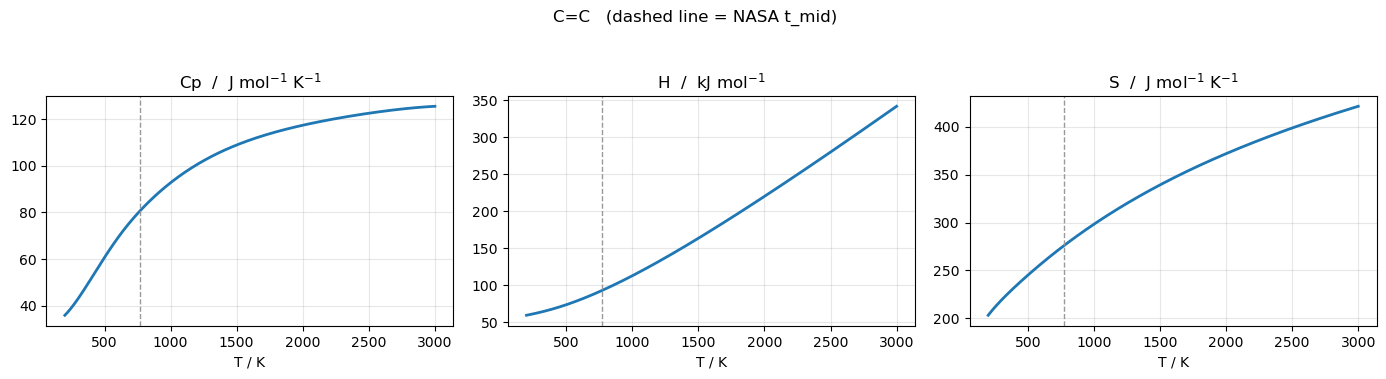

In [9]:
import matplotlib.pyplot as plt

T = list(range(max(int(nasa["t_low"]), 200), int(nasa["t_high"]) + 1, 10))
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
for axis, fn, label in zip(
    axes, (cp, h, s),
    ("Cp  /  J mol$^{-1}$ K$^{-1}$", "H  /  kJ mol$^{-1}$", "S  /  J mol$^{-1}$ K$^{-1}$"),
):
    axis.plot(T, [fn(nasa, t) for t in T], lw=2)
    axis.axvline(nasa["t_mid"], ls="--", c="0.6", lw=1)
    axis.set_xlabel("T / K")
    axis.set_title(label)
    axis.grid(alpha=0.3)
fig.suptitle(f"{SPECIES_SMILES}   (dashed line = NASA t_mid)", y=1.04)
plt.tight_layout()
plt.show()

<a id="4"></a>
## 4. Reactions and rate coefficients

Reaction search needs `reactants`, `products` or a ref to scope it — so, as in
section 1, it cannot itself tell you which reactions exist. The kinetics analytics
surface can, and every row carries the `reaction_entry_ref` the reaction endpoints take.

In [10]:
kinetics_rows = records("scientific/analytics/kinetics", limit=50)
entry_refs = list(dict.fromkeys(r["reaction_entry_ref"] for r in kinetics_rows if r.get("reaction_entry_ref")))
print(f"{len(kinetics_rows)} kinetics record(s) across {len(entry_refs)} reaction entries\n")

reactions = []
for ref in entry_refs:
    found = records("scientific/reactions/search", reaction_entry_ref=ref)
    if found:
        reactions.append(found[0])

table(
    [[r["equation"][:52], r.get("family") or "-",
      r["availability"]["kinetics_count"],
      "yes" if r["availability"]["has_transition_state"] else "no",
      "yes" if r["availability"]["has_atom_map"] else "no"]
     for r in reactions],
    ["equation", "family", "k records", "TS", "atom map"],
)

17 kinetics record(s) across 17 reaction entries



equation                                     family                              k records  TS   atom map
---------------------------------------------------------------------------------------------------------
C1=C[C]2C=CCC2C=C1 <=> C1=Cc2ccccc2C1 + [H]  R_Addition_MultipleBond             1          yes  no      
C[CH]C(CO)OO <=> CC=CCO + [O]O               R_Addition_MultipleBond             1          yes  no      
O + [CH3] <=> C + [OH]                       H_Abstraction                       1          yes  no      
C=CCCCCCCC <=> C=CC + C=CCCCC                Retroene                            1          yes  no      
F[C]F + C=C <=> FC1(F)CC1                    1+2_Cycloaddition                   1          yes  no      
[CH2]SO <=> OC[S]                            intra_OH_migration                  1          yes  no      
C[N+](=O)[O-] <=> CON=O                      intra_NO2_ONO_conversion            1          yes  no      
[CH2]CC <=> C[CH]C                           i

### One reaction, in full

`/scientific/reaction-entries/{ref}/full?include=all` assembles the reaction, its
participants, its rate coefficients and its transition states in a single response.

In [11]:
# Pick a bimolecular reaction if one exists -- its rate constant has the more
# familiar cm3/mol/s units and a clearer Arrhenius shape than a unimolecular one.
def pick(reactions):
    for r in reactions:
        if len(r["reactants"]) > 1 and r["availability"]["kinetics_count"]:
            return r
    return reactions[0]


chosen = pick(reactions)
RXN_REF = chosen["reaction_entry_ref"]

full = try_get(f"scientific/reaction-entries/{RXN_REF}/full", include="all")
entry = full["reaction_entry"]

print(f"{entry['equation']}\n")
print(f"family      {entry.get('family') or '-'}")
print(f"reversible  {entry['reversible']}")
print(f"review      {entry['review']['status']}")
print(f"atom maps   {len(entry.get('atom_maps') or [])}")

print("\nparticipants")
for side in ("reactants", "products"):
    for p in full["species"][side]:
        print(f"   {side[:-1]:8s} {p['smiles']:24s} {p['species_entry_ref']}")

O + [CH3] <=> C + [OH]

family      H_Abstraction
reversible  True
review      under_review
atom maps   0

participants
   reactant O                        spe_evwhah63tpbcfopksky6ji2diu
   reactant [CH3]                    spe_bcbdjwkip75yoziblpntwzblzu
   product  C                        spe_bg76km6tw34gcbraa75vkwkyli
   product  [OH]                     spe_2lq3jupc22nwanghcqtshffoxu


### The rate coefficient, and what backs it

A kinetics record is more than `A`, `n`, `Ea`. It carries the temperature range it was
fitted over, its uncertainty, and an **evidence checklist** — a deterministic tally of
which supporting records exist. That checklist is what lets you decide for yourself,
rather than taking a status word on faith.

In [12]:
kinetics = records(f"scientific/reaction-entries/{RXN_REF}/kinetics")
k_record = kinetics[0]
params = k_record["parameters"]

print(f"model            {k_record['model_kind']}   ({k_record['scientific_origin']})")
print(f"A                {params['A']:.6g} {params['A_units']}")
print(f"n                {params.get('n')}")
print(f"Ea               {params.get('Ea_kj_mol')} kJ/mol")
print(f"tunneling        {k_record.get('tunneling_model') or '-'}")

coverage = k_record["temperature_coverage"]
print(f"fitted over      {coverage['record_min_k']:.0f} - {coverage['record_max_k']:.0f} K")

uncertainty = k_record.get("uncertainty") or {}
print(f"A uncertainty    {uncertainty.get('A_uncertainty')} "
      f"({uncertainty.get('A_uncertainty_kind')})")

evidence = k_record.get("evidence_completeness") or {}
print(f"\nevidence         {evidence.get('score')}/{evidence.get('max')}")
for name, present in (evidence.get("checklist") or {}).items():
    print(f"   {'+' if present else '-'} {name}")

model            modified_arrhenius   (computed)
A                3025.44 cm3_mol_s
n                3.11242
Ea               39.9711 kJ/mol
tunneling        eckart
fitted over      300 - 3000 K
A uncertainty    1.24736 (multiplicative)

evidence         7/9
   + has_source_calculations
   + has_transition_state_entry
   + has_ts_opt_evidence
   + has_ts_freq_evidence
   + has_ts_sp_evidence
   + has_path_search_or_irc_evidence
   + has_uncertainty
   - has_geometry_validation
   - has_scf_stability


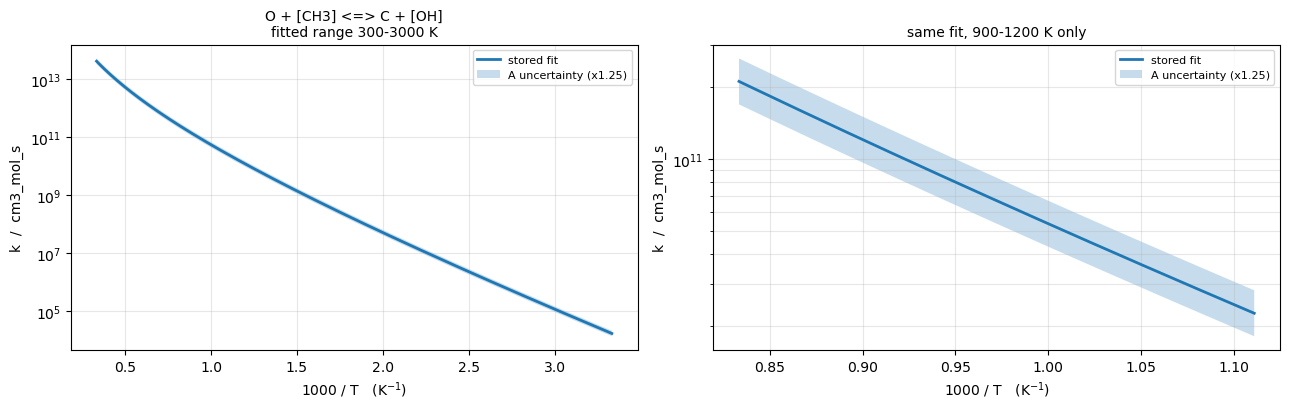

k(1000 K) = 5.373e+10 cm3_mol_s
            spanning 4.307e+10 to 6.702e+10 at the stored A uncertainty


In [13]:
def arrhenius_k(parameters, T):
    """k(T) = A * T^n * exp(-Ea / R T), in the record's own A_units."""
    return (parameters["A"]
            * T ** (parameters.get("n") or 0.0)
            * math.exp(-(parameters.get("Ea_kj_mol") or 0.0) / (R / 1000.0 * T)))


t_lo = coverage["record_min_k"] or 300.0
t_hi = coverage["record_max_k"] or 2000.0

# The stored A uncertainty is multiplicative -- a factor on k, not a +/- offset.
factor = (uncertainty.get("A_uncertainty")
          if uncertainty.get("A_uncertainty_kind") == "multiplicative" else None)


def arrhenius_panel(axis, lo, hi, title):
    temps = [lo + i * (hi - lo) / 200 for i in range(201)]
    inverse_t = [1000.0 / t for t in temps]
    k_values = [arrhenius_k(params, t) for t in temps]
    axis.semilogy(inverse_t, k_values, lw=2, label="stored fit")
    if factor:
        axis.fill_between(inverse_t,
                          [k / factor for k in k_values],
                          [k * factor for k in k_values],
                          alpha=0.25, label=f"A uncertainty (x{factor:.2f})")
    axis.set_xlabel("1000 / T   (K$^{-1}$)")
    axis.set_ylabel(f"k  /  {params['A_units']}")
    axis.set_title(title, fontsize=10)
    axis.grid(alpha=0.3, which="both")
    axis.legend(fontsize=8)


fig, (full, zoom) = plt.subplots(1, 2, figsize=(13, 4.2))
arrhenius_panel(full, t_lo, t_hi, f"{entry['equation']}\nfitted range {t_lo:.0f}-{t_hi:.0f} K")

# The band is real but invisible on the left: a x1.25 factor is under a tenth of
# a decade, against an axis spanning nine. Showing it needs a window where the
# temperature dependence does not dwarf it -- which is itself the useful lesson,
# not a plotting trick. Combustion-relevant window, clipped to the fitted range.
z_lo, z_hi = max(t_lo, 900.0), min(t_hi, 1200.0)
arrhenius_panel(zoom, z_lo, z_hi, f"same fit, {z_lo:.0f}-{z_hi:.0f} K only")

plt.tight_layout()
plt.show()

k_1000 = arrhenius_k(params, 1000.0)
print(f"k(1000 K) = {k_1000:.4g} {params['A_units']}")
if factor:
    print(f"            spanning {k_1000 / factor:.4g} to {k_1000 * factor:.4g} "
          f"at the stored A uncertainty")

<a id="5"></a>
## 5. Transition states

Saddle points are searched by **what evidence exists for them**, not by identity —
the `has_*` filters. That is the useful question for a transition state: an optimised
geometry with no frequency calculation behind it is not yet a characterised saddle point.

In [14]:
ts_records = records("scientific/transition-states/search", has_freq="true")
print(f"{len(ts_records)} transition state(s) with a frequency calculation\n")

table(
    [[t["reaction"]["equation"][:44] if t.get("reaction") else "-",
      t["transition_state"]["label"],
      t["transition_state_entry"]["status"],
      t["evidence_summary"]["calculation_count"],
      "yes" if t["evidence_summary"]["has_irc"] else "no",
      "yes" if t["evidence_summary"]["has_sp"] else "no",
      t.get("validation", {}).get("irc", "-")]
     for t in ts_records[:12]],
    ["reaction", "label", "status", "calcs", "IRC", "SP", "IRC validation"],
)

34 transition state(s) with a frequency calculation

reaction                                     label  status     calcs  IRC  SP   IRC validation
----------------------------------------------------------------------------------------------
C1=C[C]2C=CCC2C=C1 <=> C1=Cc2ccccc2C1 + [H]  TS0    optimized  4      yes  yes  absent        
C[CH]C(CO)OO <=> CC=CCO + [O]O               TS0    optimized  4      yes  yes  absent        
C#C + [CH3] <=> [CH]=CC                      TS0    optimized  2      no   no   absent        
O + [CH3] <=> C + [OH]                       TS0    optimized  4      yes  yes  absent        
C=CCCCCCCC <=> C=CC + C=CCCCC                TS0    optimized  5      yes  yes  absent        
F[C]F + C=C <=> FC1(F)CC1                    TS0    optimized  5      yes  yes  absent        
[CH2]SO <=> OC[S]                            TS0    optimized  5      yes  yes  absent        
C[N+](=O)[O-] <=> CON=O                      TS0    optimized  4      yes  yes  absent      

`IRC validation` is worth reading carefully. `absent` does **not** mean the IRC is
missing — the `IRC` column above shows the calculation exists. It means no stored
*evidence record* asserts that the IRC actually connects this saddle point to the
reactants and products the reaction claims. The calculation being present and its
conclusion being recorded are two different facts, and TCKDB keeps them separate
rather than inferring one from the other.

<a id="6"></a>
## 6. Pressure-dependent networks

A master-equation solve produces k(T,P) for every channel in a network of wells and
bimolecular states. This is where a thermochemical database stops being a table of
numbers: the stored object is a *surface*, and reading it back means evaluating a fit.

Two forms are stored here:

- **Chebyshev** — a smooth two-dimensional fit in reduced (1/T, log P);
- **PLOG** — Arrhenius expressions at fixed pressures, interpolated logarithmically.

In [15]:
nets = records("scientific/networks/search", has_channels="true")
if not nets:
    print("no pressure-dependent networks in this deployment")
else:
    for n in nets:
        info, ev = n["network"], n["evidence_summary"]
        tool = n.get("workflow_tool_release") or {}
        print(f"{info['name']}   ({tool.get('workflow_tool','?')} {tool.get('version','')})")
        print(f"   solved over {info['solve_temperature_min_k']:.0f}-{info['solve_temperature_max_k']:.0f} K, "
              f"{info['solve_pressure_min_bar']}-{info['solve_pressure_max_bar']} bar")
        print(f"   {ev['species_count']} species, {ev['state_count']} states, "
              f"{ev['channel_count']} channels, {ev['kinetics_count']} k(T,P) records")
        print(f"   forms stored: "
              f"{'Chebyshev ' if ev['has_chebyshev'] else ''}{'PLOG' if ev['has_plog'] else ''}")

NETWORK_REF = nets[0]["network"]["network_ref"] if nets else None

hydrazine   (Arkane 3.2.0)
   solved over 300-2000 K, 0.01-100.0 bar
   10 species, 7 states, 21 channels, 42 k(T,P) records
   forms stored: Chebyshev PLOG


In [16]:
detail = try_get(f"scientific/networks/{NETWORK_REF}", include="species") if NETWORK_REF else None
if detail:
    table(
        [[sp["role"], sp["canonical_smiles"], sp["species_entry_ref"], sp["species_ref"]]
         for sp in detail["record"]["species"]],
        ["role", "SMILES", "species_entry_ref", "species_ref"],
    )

role      SMILES       species_entry_ref               species_ref                   
-------------------------------------------------------------------------------------
well      NN           spe_wi6mz65sb47vzsyop3tqrqrcai  spc_654ydo5fdsxkzlo3cf7kdle5qq
well      [NH-][NH3+]  spe_zsvxdy7fbktworbhss2da62doi  spc_e5fmssd45p2zkgybqg7kazmbtm
reactant  [N-]=[NH2+]  spe_fvlbwfuoauoeknq6l5esaozqai  spc_js6c4lveb4j7w424qsjntzfjim
reactant  [H][H]       spe_7ioiqvdqm6cyumgnrammbhefum  spc_ci5wbzqmgdyiq6abljksewkef4
reactant  N=N          spe_cft35qrkqphdifcfqlcenqgdau  spc_ajemr6t7nbxrzlhbrnyshdioh4
reactant  [NH]N        spe_c4ty3ixcmyuljgqfs73pdecmte  spc_5tn7bnh3ta4grgkftj5n7kdily
reactant  [H]          spe_knzmwhplnwnpodfp6frphrl7ei  spc_orvolagcqa4ht6ldv2fecs7c7u
reactant  [NH2]        spe_gzk56q4jegyyg7ylbcdqb2xvka  spc_gnaqhl7rxotedn75vxedfcrld4
reactant  N=N          spe_qefrbgmpyryylyocpghhc2ikki  spc_ajemr6t7nbxrzlhbrnyshdioh4
bath_gas  N#N          spe_axwvieje3toq6w5qdc6ly6akca 

Note the two entries with SMILES `N=N`. They share one `species_ref` — one chemical
identity — but are two distinct `species_entry_ref`s, and the network treats them as
**separate states**. That is section 2's identity/interpretation split doing real work:
diazene has two wells, and collapsing them would merge two channels with genuinely
different rate coefficients.

It also means a channel label built from SMILES alone is **lossy**: below, three
distinct channels render as two identical-looking strings and one that appears to go
from a state to itself. The composition hashes distinguish them correctly, which is
why the pairing further down uses those rather than the labels.

In [17]:
def channel_key(record):
    """Identify a channel by the composition of the states it connects.

    Two fits of the same channel are two records with two different refs, so ref
    equality cannot pair them. The composition hashes can: they are computed from
    the participating species and stoichiometry, which is what makes "the same
    channel" the same -- and they separate states that render identically.
    """
    ch = record["network_channel"]
    return (ch["source_state_composition_hash"], ch["sink_state_composition_hash"])


def channel_label(record):
    """A readable `A + B -> C` label, built from the server's own state_label.

    Joining `canonical_smiles` with " + " is what this used to do, and it was
    lossy in exactly the case this network contains: two species_entry rows for
    diazene share one species row and therefore one `N=N`, so three different
    channels rendered as two identical strings and one that appeared to run from
    a state to itself. `state_label` carries each entry's discriminator.
    """
    ch = record["network_channel"]
    return (f"{ch['source_state']['state_label']} -> "
            f"{ch['sink_state']['state_label']}")


chebyshev = records("scientific/network-kinetics/search", has_chebyshev="true",
                    include="coefficients", limit=50)
plog = records("scientific/network-kinetics/search", has_plog="true",
               include="plog", limit=50)

print(f"{len(chebyshev)} Chebyshev fits, {len(plog)} PLOG fits")
print(f"unique channels by composition hash: "
      f"{len({channel_key(r) for r in chebyshev})} / {len({channel_key(r) for r in plog})}")
print()
table(
    [[channel_label(r)[:46], r["network_channel"]["channel_kind"],
      r["network_kinetics"]["chebyshev_shape"], r["network_kinetics"]["rate_units"]]
     for r in chebyshev[:10]],
    ["channel", "kind", "shape", "units"],
)

21 Chebyshev fits, 21 PLOG fits
unique channels by composition hash: 21 / 21

channel                               kind      shape  units    
----------------------------------------------------------------
N=N + [H][H] -> 2 [NH2]               exchange  6x4    cm3_mol_s
N=N + [H][H] -> [H] + [NH]N           exchange  6x4    cm3_mol_s
2 [NH2] -> [H] + [NH]N                exchange  6x4    cm3_mol_s
N=N + [H][H] -> [H][H] + [N-]=[NH2+]  exchange  6x4    cm3_mol_s
2 [NH2] -> [H][H] + [N-]=[NH2+]       exchange  6x4    cm3_mol_s
[H] + [NH]N -> [H][H] + [N-]=[NH2+]   exchange  6x4    cm3_mol_s
N=N + [H][H] -> N=N + [H][H]          exchange  6x4    cm3_mol_s
2 [NH2] -> N=N + [H][H]               exchange  6x4    cm3_mol_s
[H] + [NH]N -> N=N + [H][H]           exchange  6x4    cm3_mol_s
[H][H] + [N-]=[NH2+] -> N=N + [H][H]  exchange  6x4    cm3_mol_s


### Evaluating a Chebyshev fit

The Chemkin convention, which is what the stored coefficients assume:

$$\tilde{T} = \frac{2/T - 1/T_{min} - 1/T_{max}}{1/T_{max} - 1/T_{min}}
\qquad
\tilde{P} = \frac{2\log P - \log P_{min} - \log P_{max}}{\log P_{max} - \log P_{min}}$$

$$\log_{10} k(T,P) = \sum_{i}\sum_{j} a_{ij}\, \phi_i(\tilde{T})\, \phi_j(\tilde{P})
\qquad \phi_n(x) = \cos(n \arccos x)$$

Temperature is reduced in **inverse** T because Arrhenius behaviour is linear in 1/T;
pressure in **log** P because falloff is a decade-scale phenomenon. Both map the fitted
domain onto $[-1, 1]$, where the Chebyshev basis is defined.

In [18]:
def chebyshev_basis(order, x):
    return math.cos(order * math.acos(x))


def chebyshev_k(record, T, P_bar):
    """Evaluate a stored Chebyshev fit at one (T, P)."""
    meta, block = record["network_kinetics"], record["coefficients"]
    t_min, t_max = meta["tmin_k"], meta["tmax_k"]
    p_min, p_max = meta["pmin_bar"], meta["pmax_bar"]

    t_red = (2.0/T - 1.0/t_min - 1.0/t_max) / (1.0/t_max - 1.0/t_min)
    p_red = ((2.0*math.log10(P_bar) - math.log10(p_min) - math.log10(p_max))
             / (math.log10(p_max) - math.log10(p_min)))

    # Clamp to the fitted domain. Outside it the basis functions diverge, so an
    # unclamped evaluation does not extrapolate -- it produces nonsense, silently,
    # by many orders of magnitude.
    t_red = max(-1.0, min(1.0, t_red))
    p_red = max(-1.0, min(1.0, p_red))

    return 10.0 ** sum(
        c["coefficient"]
        * chebyshev_basis(c["temperature_order"], t_red)
        * chebyshev_basis(c["pressure_order"], p_red)
        for c in block["coefficients"]
    )


def plog_k(record, T, P_bar):
    """Evaluate a stored PLOG fit at one (T, P)."""
    entries = record["plog"]
    pressures = sorted({e["pressure_bar"] for e in entries})

    def arrhenius_sum(p):
        return sum(e["a"] * T**e["n"] * math.exp(-e["ea_kj_mol"] / (R/1000.0 * T))
                   for e in entries if e["pressure_bar"] == p)

    if P_bar <= pressures[0]:
        return arrhenius_sum(pressures[0])
    if P_bar >= pressures[-1]:
        return arrhenius_sum(pressures[-1])
    lo = max(p for p in pressures if p <= P_bar)
    hi = min(p for p in pressures if p >= P_bar)
    if lo == hi:
        return arrhenius_sum(lo)
    k_lo, k_hi = arrhenius_sum(lo), arrhenius_sum(hi)
    w = (math.log10(P_bar) - math.log10(lo)) / (math.log10(hi) - math.log10(lo))
    return 10 ** (math.log10(k_lo) + w * (math.log10(k_hi) - math.log10(k_lo)))

### Falloff

The point of a pressure-dependent network: k depends on pressure, and how strongly
depends on the channel. Recombination into a single well rises with pressure as
collisions stabilise the adduct; a bimolecular-to-bimolecular channel is far flatter.

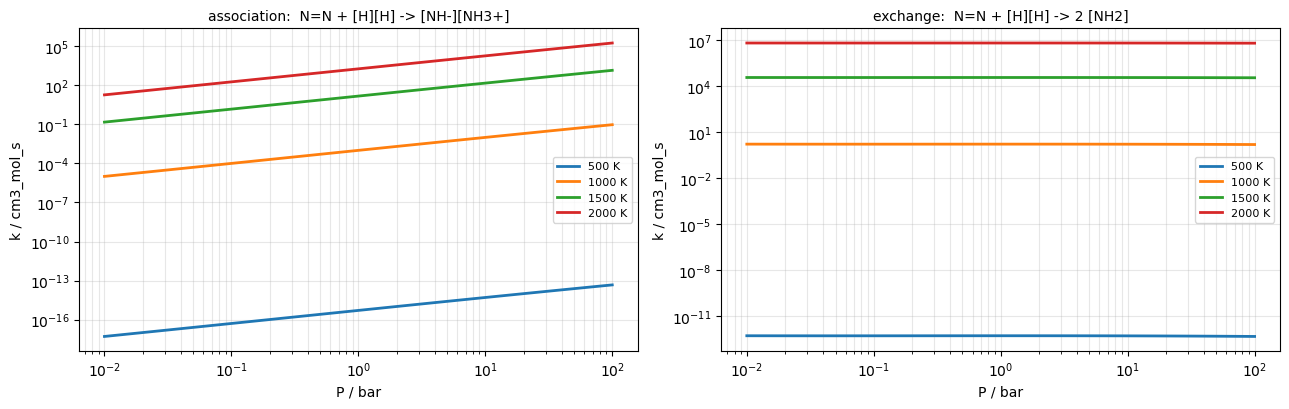

In [19]:
meta = chebyshev[0]["network_kinetics"]
pressures = [10 ** (math.log10(meta["pmin_bar"]) + i * (math.log10(meta["pmax_bar"]) - math.log10(meta["pmin_bar"])) / 60)
             for i in range(61)]

# One association (well-forming) channel and one exchange channel, for contrast.
def first_of(kind):
    return next((r for r in chebyshev if r["network_channel"]["channel_kind"] == kind), None)


fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for axis, kind in zip(axes, ("association", "exchange")):
    rec = first_of(kind)
    if rec is None:
        axis.set_title(f"no {kind} channel")
        continue
    for T in (500.0, 1000.0, 1500.0, 2000.0):
        axis.loglog(pressures, [chebyshev_k(rec, T, p) for p in pressures],
                    lw=2, label=f"{T:.0f} K")
    axis.set_xlabel("P / bar")
    axis.set_ylabel(f"k / {rec['network_kinetics']['rate_units']}")
    axis.set_title(f"{kind}:  {channel_label(rec)[:40]}", fontsize=10)
    axis.grid(alpha=0.3, which="both")
    axis.legend(fontsize=8)
plt.tight_layout()
plt.show()

### A self-consistency check

This network was fitted **twice** — Chebyshev from one master-equation run, PLOG from
a sister run of the same network with a different interpolation model. Two independent
fits of the same physics is a redundancy, and redundancy is where a database can be
checked against itself: evaluating both at the same (T, P) tests the stored numbers
rather than just reading them back.

In [20]:
plog_by_key = {channel_key(r): r for r in plog}
pairs = [(c, plog_by_key[channel_key(c)]) for c in chebyshev if channel_key(c) in plog_by_key]
print(f"{len(pairs)} of {len(chebyshev)} channels stored in both forms\n")

rows = []
for cheb, pl in pairs:
    k_c, k_p = chebyshev_k(cheb, 1000.0, 1.0), plog_k(pl, 1000.0, 1.0)
    rows.append((abs(math.log10(k_c/k_p)), channel_label(cheb),
                 cheb["network_channel"]["channel_kind"], k_c, k_p))
rows.sort()

table(
    [[lab[:40], kind, f"{k_c:.4g}", f"{k_p:.4g}", f"{k_c/k_p:.3f}"]
     for _, lab, kind, k_c, k_p in rows],
    ["channel", "kind", "k Chebyshev", "k PLOG", "ratio"],
)
print(f"\nat 1000 K, 1 bar, units {chebyshev[0]['network_kinetics']['rate_units']}")

21 of 21 channels stored in both forms

channel                               kind           k Chebyshev  k PLOG     ratio
----------------------------------------------------------------------------------
N=N + [H][H] -> 2 [NH2]               exchange       1.693        1.671      1.013
N=N + [H][H] -> [H][H] + [N-]=[NH2+]  exchange       8.869e-05    8.715e-05  1.018
N=N + [H][H] -> [H] + [NH]N           exchange       0.001471     0.00157    0.937
[H] + [NH]N -> [H][H] + [N-]=[NH2+]   exchange       8.294e+10    8.934e+10  0.928
2 [NH2] -> [H] + [NH]N                exchange       1.737e+08    1.894e+08  0.917
[H] + [NH]N -> N=N + [H][H]           exchange       1.194e+08    1.339e+08  0.892
2 [NH2] -> [H][H] + [N-]=[NH2+]       exchange       2.579e+07    2.245e+07  1.148
2 [NH2] -> N=N + [H][H]               exchange       3195         3730       0.857
N=N + [H][H] -> N=N + [H][H]          exchange       8.86e-08     1.053e-07  0.842
[H][H] + [N-]=[NH2+] -> N=N + [H][H]  exchange 

Sorting by disagreement sorts by `kind`, which is not a coincidence.

Every `exchange` channel — bimolecular in, bimolecular out — agrees to within about
20%. Every channel that ends in a collisionally stabilised well (`association`, and the
one `isomerization`) disagrees by more, up to a factor of about 4. And the drift is
**one-directional**: for all of them the Chebyshev value is the lower one. A systematic
offset along a physically meaningful axis is not scatter, and it is not a bug in either
evaluator — a coding error in the reduced coordinates or the basis would spoil the
`exchange` channels too.

What it is, exactly, this notebook cannot say: two fitting forms, fitted from two
separate master-equation runs, need not agree where the surface is hardest to fit. What
it *is* good for is calibration — it bounds how much precision to claim from a fitted
k(T,P), and it says the bound is much tighter for exchange channels than for
stabilisation.

Note what this check does not do. It does not certify that the network is right; both
fits could descend from the same wrong solve. It bounds the disagreement between two
representations of one calculation — a more modest claim, and the one the data
supports. A stored number you can only read back is a number you have to take on
faith; a stored number you can *rebuild two ways* tells you something when the two
ways disagree.

<a id="7"></a>
## 7. How much should you trust this?

Every scientific record carries a review state. TCKDB deliberately keeps three
*separate* judgements rather than collapsing them into one score:

| | question it answers |
|---|---|
| **review** | has a human curator signed off? |
| **trust** | is the supporting evidence complete? |
| **reproducibility** | is enough deposited to audit or re-run it? |

They can legitimately disagree — a well-evidenced record may be unreviewed, and a
reviewed record may still lack the artifacts needed to reproduce it. Collapsing them
would hide exactly the distinction a reader needs.

In [21]:
# Every search response carries a review roll-up for free.
summary = get("scientific/thermo/search", species_ref=SPECIES_REF)["review_summary"]
print("review summary:", summary)

# Heavier blocks are opt-in. Ask for an illegal token and the server tells you
# exactly which are legal for that endpoint -- a fast way to explore the API.
try:
    get("scientific/thermo/search", species_ref=SPECIES_REF, include="not_a_real_token")
except TCKDBError as exc:
    print(f"\ncode   {exc.code}")
    print(f"detail {exc.detail}")

review summary: {'approved': 0, 'under_review': 7, 'not_reviewed': 0, 'deprecated': 0, 'rejected': 0, 'total': 7}



code   unknown_include_token
detail unknown_include_token: token(s) ['not_a_real_token'] not legal for /scientific/thermo/search. Legal tokens: ['artifacts', 'assessments', 'calculations', 'internal_ids', 'provenance', 'review', 'all']


### A worked trust block

`include=trust` on a calculation returns the deterministic evidence evaluation — the
rubric that ran, the checks it passed, and the label it concluded.

In [22]:
# Any calculation from this deployment; take the first the analytics surface reports.
calc_rows = records("scientific/analytics/calculations", limit=1)
CALC_REF = calc_rows[0]["calculation_ref"] if calc_rows else None

detail = try_get(f"scientific/calculations/{CALC_REF}", include="trust") if CALC_REF else None
trust = (detail or {}).get("record", {}).get("trust")

if trust:
    print(f"calculation  {CALC_REF}")
    print(f"review       {trust['review_status']}")
    print(f"trust        {trust['trust_status']}")
    ev = trust["evidence"]
    print(f"rubric       {ev['rubric']} v{ev['rubric_version']}  ->  {ev['label']}\n")
    for check in ev.get("passed_checks", []) or []:
        print("   +", check)
    for check in ev.get("missing_checks", []) or []:
        print("   -", check, "(missing)")
else:
    print("no trust block available for this record")

calculation  calc_heds3dt3dsqxmqkcchibvbtwi4
review       under_review
trust        mostly_supported
rubric       computed_calculation_v1 v1  ->  mostly_supported

   + calculation_has_owner
   + calculation_type_present
   + level_of_theory_present
   + software_release_present
   + workflow_tool_release_present
   + input_geometry_present
   + output_geometry_present
   + result_block_present
   + calculation_dependencies_present_when_expected
   - quality_recorded (missing)
   - artifacts_present (missing)
   - parameters_parsed (missing)


## Where to go next

Endpoints this tour did not use:

| endpoint | what it gives you |
|---|---|
| `scientific/calculations/{ref}?include=all` | one calculation in full — geometries, artifacts, parameters |
| `scientific/calculations/{ref}/irc` | the intrinsic reaction coordinate path |
| `scientific/conformers/search` | conformer groups and observations |
| `scientific/transport/search` | Lennard-Jones parameters |
| `scientific/artifacts/search` | the deposited output files themselves |
| `scientific/export/ndjson`, `export/ml/*.ndjson` | bulk export, and ML-ready feature rows |
| `scientific/releases` | citable, frozen dataset releases |
| `lookup/*` | a lighter lookup family returning `{query, match, results}` |

Two conventions worth remembering:

- **`include=`** opts into heavier blocks. Anything omitted by default is omitted on
  purpose — the default response stays small and predictable. Pass a nonsense token to
  be told the legal ones, as in section 7.
- **every search response carries `pagination`** with a true `total`, so you always know
  whether you are looking at everything.

### Using the typed client instead

```
pip install tckdb-client
```
```python
from tckdb_client import TCKDBClient

with TCKDBClient(base_url="https://tckdb.homecalvin.com") as client:
    print(client.health())
```

Match the client version to the deployment: a client built against a newer contract
will 404 on endpoints an older server does not serve yet.

---
*Read-only tour. The script form is `explore_tckdb.py` in this directory —
`python examples/clients/explore_tckdb.py` prints the same tour without plots, and
every function in it is importable.*